<h2>Regression Algorithms</h2>
<br> Distance Based: Linear Regression, Polynomial Regression, Ridge, Lasso, Support Vector Machine Regressor
<br> Tree based: Decision Tree and Random Forest
<br><br>
Libraries: pandas, numpy, matplotlib, sklearn (Scikit-learn)
<br><br>
Imputer: replace missing values: strategy for replace missing values in numeric is replace with mean and for categorical is to use mode
<br>
Scaler: scale the data of multiple columns to similar range of values
<br>
Encoding: Convert categorical data into numeric data
<br>
We follow the steps: Imputer to Scaling to Encoding - and we need to check numeric or categorical column before performing these. Instead of manually doing all these, we can create a pipeline and tell it how and what to perform. 



In [1]:
# Install the libraries that you dont already have
# pip install pandas numpy matplotlib statsmodels scikit-learn
# install it at python home
import sys
print("Python Home: ",sys.prefix)


Python Home:  D:\Python314


In [18]:
# Step 0: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#section 1: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from statsmodels.stats.outliers_influence import variance_inflation_factor

#section 2: building the model - training the model
# calling the respective algorithm
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# section 3: post processing
# Model evaluation: metric
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

#deployment 
import joblib

#ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")


In [19]:
# Step 1: Gather data
file="https://raw.githubusercontent.com/swapnilsaurav/MachineLearning/refs/heads/master/Examples/Regression/ml_regression_property_dataset.csv"
df = pd.read_csv(file)
print(df.shape)
print("Column Names: ",df.columns.tolist())

(1000, 26)
Column Names:  ['Property_ID', 'Listing_Date', 'City', 'Locality', 'Property_Type', 'BHK', 'Built_Up_Area_sqft', 'Carpet_Area_sqft', 'Age_Years', 'Floor', 'Total_Floors', 'Bathrooms', 'Parking_Spaces', 'Furnishing_Status', 'Facing', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_CBD_km', 'Nearby_Schools', 'Crime_Index', 'Amenities_Score', 'Monthly_Maintenance_INR', 'Seller_Type', 'Loan_Available', 'Annual_Property_Tax_INR', 'Price_Lakhs']


The ML Objective is to predict residential property price based on location, area, property characteristics.

In [20]:
target_column="Price_Lakhs"
print("Target column:",target_column)

Target column: Price_Lakhs


In [21]:
# Step 2: Data Preparation
print("DF Information")
print(df.info())

print("\n\nCheck Missing Values")
missing_values = df.isnull().sum()
print(missing_values[missing_values>0])
missing_pct = (df.isnull().sum()/len(df)) * 100
print("\n\nCheck Missing Values %")
print(missing_pct[missing_pct>0])

print("\n\nCheck Duplicate Records")
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:\n",duplicate_count)
print("Display duplicate rows:")
df_dup = df[df.duplicated(keep=False)].sort_values(by="Property_ID")
print(df_dup)
print("lets now remove duplicates")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after drop of duplicate rows=",df.shape)


print("Check Unique values:")
categorical_columns_1 = df.select_dtypes(include=['object'])
for column in categorical_columns_1:
    print("\n Column:",column)
    print(df[column].unique())

DF Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Property_ID              1000 non-null   object 
 1   Listing_Date             1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Locality                 1000 non-null   object 
 4   Property_Type            1000 non-null   object 
 5   BHK                      1000 non-null   int64  
 6   Built_Up_Area_sqft       975 non-null    float64
 7   Carpet_Area_sqft         946 non-null    float64
 8   Age_Years                959 non-null    float64
 9   Floor                    1000 non-null   object 
 10  Total_Floors             1000 non-null   int64  
 11  Bathrooms                1000 non-null   int64  
 12  Parking_Spaces           1000 non-null   int64  
 13  Furnishing_Status        966 non-null    object 
 14  Facing    

In [22]:
# STEP 3: Data Wrangling
#lets clean City
df["City"] = (df["City"].astype(str).str.strip().str.title())
df["City"] = df["City"].replace({"Delhi Ncr":"Delhi NCR"})

#Now lets clean Furnishing_Status
df["Furnishing_Status"] = (df["Furnishing_Status"].astype(str).str.strip().str.title())
df["Furnishing_Status"] = df["Furnishing_Status"].replace("-"," ",regex=False)
furnish_map = {
    'Unfurnished':'Unfurnished',
    'Semi Furnished':'Semi Furnished',
    'Furnished':'Furnished',
    'nan':np.nan,
}
df["Furnishing_Status"] = df["Furnishing_Status"].map(furnish_map)
    
df["Gated_Community"] = (df["Gated_Community"].astype(str).str.strip().str.title())
gated_map = {
    "Yes":"Yes",
    "No":"No",
    "Y":"Yes",
    "N":"No"
}
df["Gated_Community"] = df["Gated_Community"].map(gated_map)

#clean Floor column
def clean_floor_data(value):
    if pd.isna(value):
        return np.nan
    if value.lower()=="ground":
        return 0
    value = (
        value
        .replace("st","")
        .replace("nd","")
        .replace("rd","")
        .replace("th","")
    )
    try:
        return int(value)
    except:
        return np.nan
#apply above function to Floor column and save in another column
df['Floor_Numeric'] = df['Floor'].apply(clean_floor_data)
print(df[['Floor','Floor_Numeric']].head(20))


print("Check Unique values:")
categorical_columns_1 = df.select_dtypes(include=['object'])
for column in categorical_columns_1:
    if column not in ['Property_ID','Listing_Date']:
        print("\n Column:",column)
        print(df[column].unique())

Columns_to_drop = ['Floor','Property_ID']

     Floor  Floor_Numeric
0   Ground              0
1        6              6
2        8              8
3       11             11
4      3rd              3
5   Ground              0
6        7              7
7        3              3
8       14             14
9   Ground              0
10       9              9
11       5              5
12     2nd              2
13      11             11
14      19             19
15      21             21
16  Ground              0
17      14             14
18       1              1
19     1st              1
Check Unique values:

 Column: City
['Pune' 'Bengaluru' 'Delhi NCR' 'Hyderabad' 'Chennai']

 Column: Locality
['Hinjewadi' 'Whitefield' 'Noida' 'Marathahalli' 'Gurugram' 'Baner'
 'HSR Layout' 'Kukatpally' 'Electronic City' 'Madhapur' 'Ghaziabad'
 'Velachery' 'Yelahanka' 'Anna Nagar' 'Gachibowli' 'OMR' 'Kondapur'
 'Wakad' 'Porur' 'Kharadi' 'Dwarka' 'Manikonda' 'Tambaram' 'Hadapsar'
 'Faridabad']

 Column: Property_Type
['Villa' 'Apartment' 'Independen

In [23]:
# STEP 3: DATA WRANGLING

df['Listing_Date'] = pd.to_datetime(df['Listing_Date'],errors="coerce")
# Feature Engineering
df['Listing_Year'] = df['Listing_Date'].dt.year
df['Listing_Month'] = df['Listing_Date'].dt.month
df['Listing_Quarter'] = df['Listing_Date'].dt.quarter

#create recency feature
reference_date = df['Listing_Date'].max()
df['Days_Since_Listing'] = (reference_date - df['Listing_Date']).dt.days

Columns_to_drop.append('Listing_Date')
df = df.drop(columns=Columns_to_drop)

<h3> Exploratory Data Analysis </h3>
We visualize the data to understand the relationship between different features and also features with target variable

In [24]:
print("Shape of DF: ",df.shape)
print("Columns in DF: ",df.columns)

Shape of DF:  (990, 28)
Columns in DF:  Index(['City', 'Locality', 'Property_Type', 'BHK', 'Built_Up_Area_sqft',
       'Carpet_Area_sqft', 'Age_Years', 'Total_Floors', 'Bathrooms',
       'Parking_Spaces', 'Furnishing_Status', 'Facing', 'Gated_Community',
       'Distance_to_Metro_km', 'Distance_to_CBD_km', 'Nearby_Schools',
       'Crime_Index', 'Amenities_Score', 'Monthly_Maintenance_INR',
       'Seller_Type', 'Loan_Available', 'Annual_Property_Tax_INR',
       'Price_Lakhs', 'Floor_Numeric', 'Listing_Year', 'Listing_Month',
       'Listing_Quarter', 'Days_Since_Listing'],
      dtype='object')


Property Price Distribution


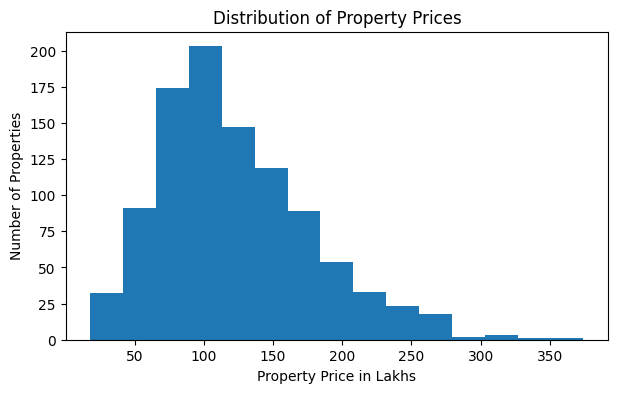

Built up Area and Price - Correlation


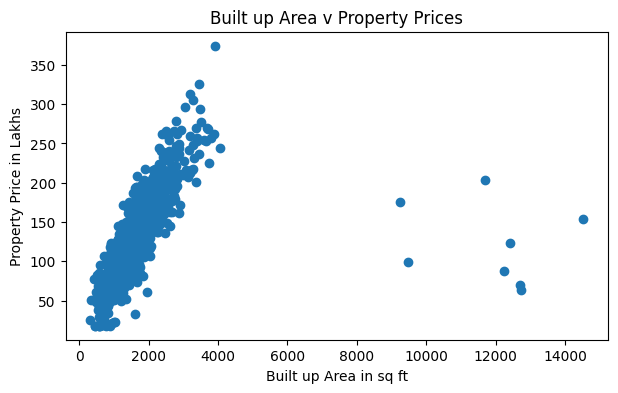

Age in Years and Price - Correlation


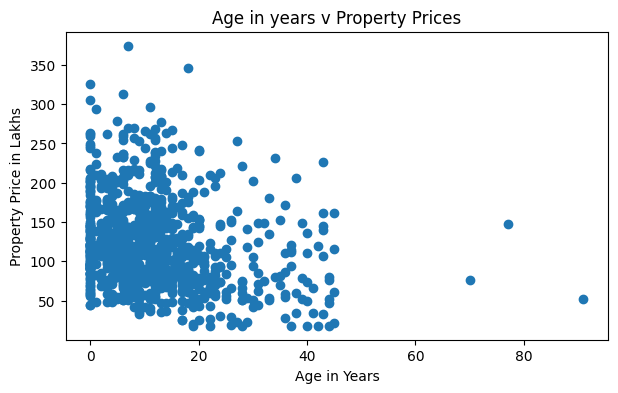

Boxplot to check the Outliers


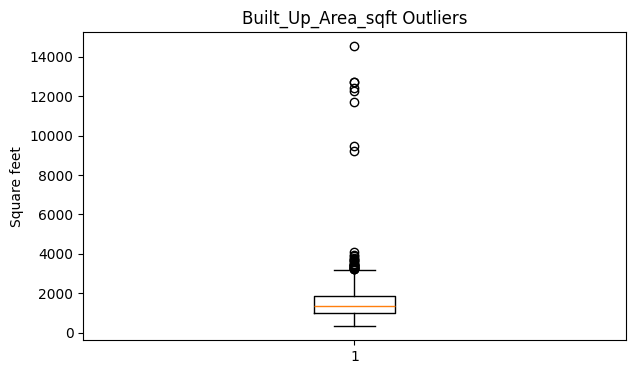

Boxplot to check the Outliers


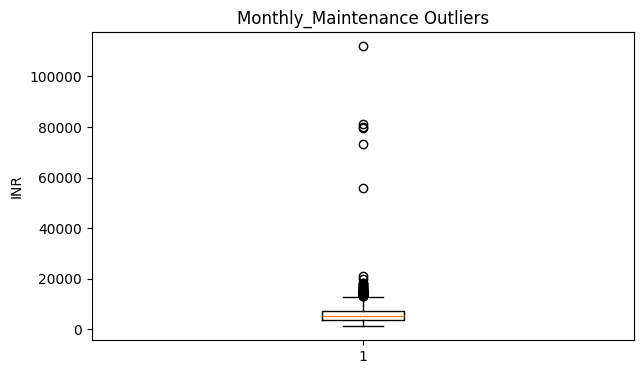

In [25]:
print("Property Price Distribution")
plt.figure(figsize=(7,4))
plt.hist(df['Price_Lakhs'], bins=15)
plt.xlabel("Property Price in Lakhs")
plt.ylabel("Number of Properties")
plt.title("Distribution of Property Prices")
plt.show()

print("Built up Area and Price - Correlation")
plt.figure(figsize=(7,4))
plt.scatter(df['Built_Up_Area_sqft'], df['Price_Lakhs'])
plt.xlabel("Built up Area in sq ft")
plt.ylabel("Property Price in Lakhs")
plt.title("Built up Area v Property Prices")
plt.show()

print("Age in Years and Price - Correlation")
plt.figure(figsize=(7,4))
plt.scatter(df['Age_Years'], df['Price_Lakhs'])
plt.xlabel("Age in Years")
plt.ylabel("Property Price in Lakhs")
plt.title("Age in years v Property Prices")
plt.show()

print("Boxplot to check the Outliers")
plt.figure(figsize=(7,4))
plt.boxplot(df['Built_Up_Area_sqft'].dropna())
plt.ylabel("Square feet")
plt.title("Built_Up_Area_sqft Outliers")
plt.show()


print("Boxplot to check the Outliers")
plt.figure(figsize=(7,4))
plt.boxplot(df['Monthly_Maintenance_INR'].dropna())
plt.ylabel("INR")
plt.title("Monthly_Maintenance Outliers")
plt.show()

In [26]:
print("Checking for Multicollinearity")
corr_df = df[['Built_Up_Area_sqft','Carpet_Area_sqft','BHK','Bathrooms',
              'Monthly_Maintenance_INR','Annual_Property_Tax_INR']].corr()
print(corr_df)

#VIF Analysis
vif_columns_df = df[['Built_Up_Area_sqft','Carpet_Area_sqft','BHK','Bathrooms',
              'Monthly_Maintenance_INR','Annual_Property_Tax_INR','Distance_to_Metro_km','Distance_to_CBD_km',
                    'Parking_Spaces','Age_Years']]

#replace the missing values with median values
for column in vif_columns_df.columns:
    vif_columns_df[column] = vif_columns_df[column].fillna(vif_columns_df[column].median())
vif_result = pd.DataFrame()
vif_result['Feature'] = vif_columns_df.columns
vif_result['VIF_Score'] = [variance_inflation_factor(vif_columns_df.values,i) for i in range(vif_columns_df.shape[1]) ] 

print("VIF Score: \n",vif_result)

Checking for Multicollinearity
                         Built_Up_Area_sqft  Carpet_Area_sqft       BHK  \
Built_Up_Area_sqft                 1.000000          0.551675  0.498809   
Carpet_Area_sqft                   0.551675          1.000000  0.874344   
BHK                                0.498809          0.874344  1.000000   
Bathrooms                          0.433262          0.770229  0.865565   
Monthly_Maintenance_INR            0.191849          0.385823  0.318653   
Annual_Property_Tax_INR            0.491377          0.844931  0.760420   

                         Bathrooms  Monthly_Maintenance_INR  \
Built_Up_Area_sqft        0.433262                 0.191849   
Carpet_Area_sqft          0.770229                 0.385823   
BHK                       0.865565                 0.318653   
Bathrooms                 1.000000                 0.272671   
Monthly_Maintenance_INR   0.272671                 1.000000   
Annual_Property_Tax_INR   0.682620                 0.316638   

 

In [27]:
# Separate Features and Target
X = df.drop(columns=['Price_Lakhs'])
y = df['Price_Lakhs']

print("X Shape: ",X.shape)
print("y Shape: ",y.shape)

print("Train Test Split")
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)
print("X train Shape: ",X_train.shape)
print("y train Shape: ",y_train.shape)
print("X test Shape: ",X_test.shape)
print("y test Shape: ",y_test.shape)

X Shape:  (990, 27)
y Shape:  (990,)
Train Test Split
X train Shape:  (792, 27)
y train Shape:  (792,)
X test Shape:  (198, 27)
y test Shape:  (198,)


In [28]:
#Identify Numerical Features
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
print("Numerical features:\n",numerical_features)

#numerical preprocessing pipeline
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                      ("scaler",StandardScaler())])

#Identify Categorical Features
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
print("Categorical features:\n",categorical_features)

#Categorical preprocessing pipeline
category_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                      ("encoder",OneHotEncoder(handle_unknown="ignore"))])

#Column Transformer
preprocessor = ColumnTransformer(
    transformers=[("numeric",numeric_transformer,numerical_features),
                  ("categorical",category_transformer,categorical_features)]
)

Numerical features:
 ['BHK', 'Built_Up_Area_sqft', 'Carpet_Area_sqft', 'Age_Years', 'Total_Floors', 'Bathrooms', 'Parking_Spaces', 'Distance_to_Metro_km', 'Distance_to_CBD_km', 'Nearby_Schools', 'Crime_Index', 'Amenities_Score', 'Monthly_Maintenance_INR', 'Annual_Property_Tax_INR', 'Floor_Numeric', 'Listing_Year', 'Listing_Month', 'Listing_Quarter', 'Days_Since_Listing']
Categorical features:
 ['City', 'Locality', 'Property_Type', 'Furnishing_Status', 'Facing', 'Gated_Community', 'Seller_Type', 'Loan_Available']


In [29]:
# Creating a Baseline Model
baseline_prediction = np.repeat(y_train.mean(), len(y_test))

In [30]:
#Model Evaluation
baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_mse = mean_squared_error(y_test, baseline_prediction)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_prediction)
print("Baseline Evaluation")
print("baseline_mae: ",baseline_mae)
print("baseline_rmse: ",baseline_rmse)
print("baseline_r2: ",baseline_r2)

Baseline Evaluation
baseline_mae:  43.329534231200896
baseline_rmse:  55.16621966233019
baseline_r2:  -0.002910747885427334


<h3> Building Our First Model: Simple Linear Regression </h3>
SLR: Use 1 single column of X (Independent variable) to predict y


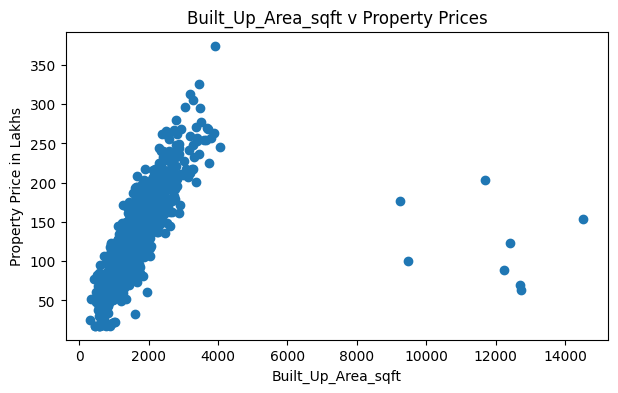

Build Simple Linear Regression Model
SLR Equation: Y= 0.023040100962963005 X + 85.43888151478578
Simple Linear Regression Evaluation
slr_mae:  34.12235113542214
slr_rmse:  45.59916716246654
slr_r2:  0.2889215650894742


In [31]:
simple_data = df[['Built_Up_Area_sqft','Price_Lakhs']].dropna()
plt.figure(figsize=(7,4))
plt.scatter(simple_data['Built_Up_Area_sqft'], simple_data['Price_Lakhs'])
plt.xlabel("Built_Up_Area_sqft")
plt.ylabel("Property Price in Lakhs")
plt.title("Built_Up_Area_sqft v Property Prices")
plt.show()

X_train,X_test, y_train, y_test = train_test_split(simple_data[['Built_Up_Area_sqft']],
                                                   simple_data['Price_Lakhs'], test_size=0.20, random_state=10)

print("Build Simple Linear Regression Model")
slr_model = LinearRegression() #create SLR object
#train the data
slr_model.fit(X_train,y_train)
m = slr_model.coef_[0]
c = slr_model.intercept_
print(f"SLR Equation: Y= {m} X + {c}")

#Prediction
slr_pred = slr_model.predict(X_test)

#Model Evaluation
slr_mae = mean_absolute_error(y_test, slr_pred)
slr_mse = mean_squared_error(y_test, slr_pred)
slr_rmse = np.sqrt(slr_mse)
slr_r2 = r2_score(y_test, slr_pred)
print("Simple Linear Regression Evaluation")
print("slr_mae: ",slr_mae)
print("slr_rmse: ",slr_rmse)
print("slr_r2: ",slr_r2)


In [36]:
#MULTIPLE LINEAR REGRESSION
import time

mlr_pipeline = Pipeline(steps=[("preprocessor",preprocessor),
                              ("regression",LinearRegression())])


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)

print("Build Multiple Linear Regression Model")
st_time = time.perf_counter()
#train the data
mlr_pipeline.fit(X_train,y_train)

#m = slr_model.coef_[0]
#c = slr_model.intercept_

#Prediction
mlr_pred = mlr_pipeline.predict(X_test)

#Model Evaluation
mlr_mae = mean_absolute_error(y_test, mlr_pred)
mlr_mse = mean_squared_error(y_test, mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_r2 = r2_score(y_test, mlr_pred)
print("Multiple Linear Regression Evaluation")
print("mlr_mae: ",mlr_mae)
print("mlr_rmse: ",mlr_rmse)
print("mlr_r2: ",mlr_r2)
ed_time = time.perf_counter()
print("Total time taken (seconds):",ed_time - st_time)


Build Multiple Linear Regression Model
Multiple Linear Regression Evaluation
mlr_mae:  12.93951413667939
mlr_rmse:  16.17131475660816
mlr_r2:  0.9138199985040187
Total time taken (seconds): 0.09669949999079108


In [40]:
# DIMENSIONALITY REDUCTION (Efficiency v Accuracy)
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

mlr_pipeline = Pipeline(steps=[("preprocessor",preprocessor),
                               ('feature_selection',SelectKBest(score_func = f_regression, k=20)),
                              ("regression",LinearRegression())])


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)

print("Build Multiple Linear Regression Model")
st_time = time.perf_counter()
#train the data
mlr_pipeline.fit(X_train,y_train)

#Prediction
mlr_pred = mlr_pipeline.predict(X_test)

#Model Evaluation
mlr_mae = mean_absolute_error(y_test, mlr_pred)
mlr_mse = mean_squared_error(y_test, mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_r2 = r2_score(y_test, mlr_pred)
print("Multiple Linear Regression Evaluation with SelectKBest")
print("mlr_mae: ",mlr_mae)
print("mlr_rmse: ",mlr_rmse)
print("mlr_r2: ",mlr_r2)
ed_time = time.perf_counter()
print("Total time taken (seconds):",ed_time - st_time)

#Dimensionality Reduction using PCA
mlr_pipeline = Pipeline(steps=[("preprocessor",preprocessor),
                               ('pca',PCA(n_components=20)),
                              ("regression",LinearRegression())])


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)

print("Build Multiple Linear Regression Model")
st_time = time.perf_counter()
#train the data
mlr_pipeline.fit(X_train,y_train)

#Prediction
mlr_pred = mlr_pipeline.predict(X_test)

#Model Evaluation
mlr_mae = mean_absolute_error(y_test, mlr_pred)
mlr_mse = mean_squared_error(y_test, mlr_pred)
mlr_rmse = np.sqrt(mlr_mse)
mlr_r2 = r2_score(y_test, mlr_pred)
print("\n\nMultiple Linear Regression Evaluation with PCA")
print("mlr_mae: ",mlr_mae)
print("mlr_rmse: ",mlr_rmse)
print("mlr_r2: ",mlr_r2)
ed_time = time.perf_counter()
print("Total time taken (seconds):",ed_time - st_time)


Build Multiple Linear Regression Model
Multiple Linear Regression Evaluation with SelectKBest
mlr_mae:  13.210917067426045
mlr_rmse:  16.8655914755469
mlr_r2:  0.9062612863026601
Total time taken (seconds): 0.08531460000085644
Build Multiple Linear Regression Model


Multiple Linear Regression Evaluation with PCA
mlr_mae:  13.949764364801384
mlr_rmse:  18.001580095517273
mlr_r2:  0.8932084005644634
Total time taken (seconds): 0.37879249997786246


In [41]:
# RIDGE & LASSO Regression

ridge_pipeline = Pipeline(steps=[("preprocessor",preprocessor),
                              ("regression",Ridge(alpha=0.7))])


X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)

print("Build Ridge Regression Model")
st_time = time.perf_counter()
#train the data
ridge_pipeline.fit(X_train,y_train)

#m = slr_model.coef_[0]
#c = slr_model.intercept_

#Prediction
ridge_pred = ridge_pipeline.predict(X_test)

#Model Evaluation
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)
print("Ridge Regression Evaluation")
print("mlr_mae: ",ridge_mae)
print("mlr_rmse: ",ridge_rmse)
print("mlr_r2: ",ridge_r2)
ed_time = time.perf_counter()
print("Total time taken (seconds):",ed_time - st_time)

Build Ridge Regression Model
Ridge Regression Evaluation
mlr_mae:  12.876046464668645
mlr_rmse:  16.11455900343864
mlr_r2:  0.9144238612984192
Total time taken (seconds): 0.07056639998336323


In [45]:
#LASSO
# 0.05 to 0.15 - 0.07
for i in range(5,15):
    lasso_pipeline = Pipeline(steps=[("preprocessor",preprocessor),
                                  ("regression",Lasso(alpha=i/100))])
    
    
    X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=10)
    
    print("Build lasso Regression Model")
    st_time = time.perf_counter()
    #train the data
    lasso_pipeline.fit(X_train,y_train)
    
    #Prediction
    lasso_pred = lasso_pipeline.predict(X_test)
    
    #Model Evaluation
    lasso_mae = mean_absolute_error(y_test, lasso_pred)
    lasso_mse = mean_squared_error(y_test, lasso_pred)
    lasso_rmse = np.sqrt(lasso_mse)
    lasso_r2 = r2_score(y_test, lasso_pred)
    print("lasso Regression Evaluation: alpha=",i)
    print("lasso_mae: ",lasso_mae)
    print("lasso_rmse: ",lasso_rmse)
    print("lasso_r2: ",lasso_r2)
    ed_time = time.perf_counter()
    print("Total time taken (seconds):",ed_time - st_time)

Build lasso Regression Model
lasso Regression Evaluation: alpha= 5
lasso_mae:  12.546120153524692
lasso_rmse:  15.922417383294327
lasso_r2:  0.916452425729479
Total time taken (seconds): 0.048606299998937175
Build lasso Regression Model
lasso Regression Evaluation: alpha= 6
lasso_mae:  12.486681270197762
lasso_rmse:  15.898023622034556
lasso_r2:  0.9167082258826474
Total time taken (seconds): 0.09732309999526478
Build lasso Regression Model
lasso Regression Evaluation: alpha= 7
lasso_mae:  12.441787855082827
lasso_rmse:  15.884098307458096
lasso_r2:  0.9168540749784437
Total time taken (seconds): 0.062152400001650676
Build lasso Regression Model
lasso Regression Evaluation: alpha= 8
lasso_mae:  12.407823433187176
lasso_rmse:  15.868609032355593
lasso_r2:  0.9170161543300466
Total time taken (seconds): 0.09021550000761636
Build lasso Regression Model
lasso Regression Evaluation: alpha= 9
lasso_mae:  12.3798404484021
lasso_rmse:  15.853580681416789
lasso_r2:  0.917173259444314
Total time

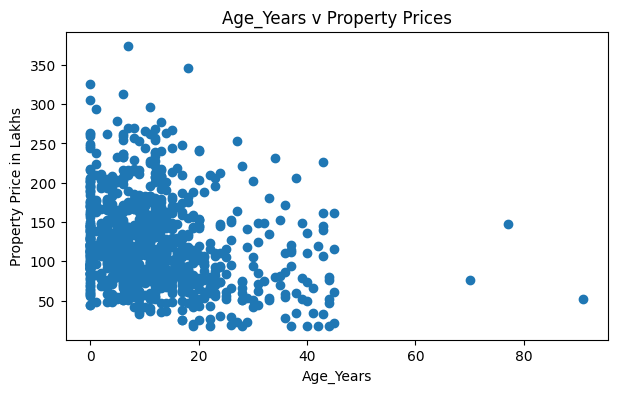

Build polynomial Regression Model
polynomial Regression Evaluation
poly_mae:  43.54288930529112
poly_rmse:  53.731526206496156
poly_r2:  0.05622868616946053


In [49]:
# POLYNOMIAL :  m1 x1 + m2 x square + m3 x cube + ...
poly_data = df[['Age_Years','Price_Lakhs']].dropna()
plt.figure(figsize=(7,4))
plt.scatter(poly_data['Age_Years'], poly_data['Price_Lakhs'])
plt.xlabel("Age_Years")
plt.ylabel("Property Price in Lakhs")
plt.title("Age_Years v Property Prices")
plt.show()

X_train,X_test, y_train, y_test = train_test_split(poly_data[['Age_Years']],
                                                   poly_data['Price_Lakhs'], test_size=0.20, random_state=10)

print("Build polynomial Regression Model")
poly_transform = PolynomialFeatures(degree=2)

#transform the data into Polynomial format and use Linear Regression to predict.
#transform
X_train_poly_transform = (poly_transform.fit_transform(X_train))
X_test_poly_transform = (poly_transform.transform(X_test))

# now build the regression model
poly_model =LinearRegression()
#train the data
poly_model.fit(X_train_poly_transform,y_train)

#Prediction
poly_pred = poly_model.predict(X_test_poly_transform)

#Model Evaluation
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(y_test, poly_pred)
print("polynomial Regression Evaluation")
print("poly_mae: ",poly_mae)
print("poly_rmse: ",poly_rmse)
print("poly_r2: ",poly_r2)


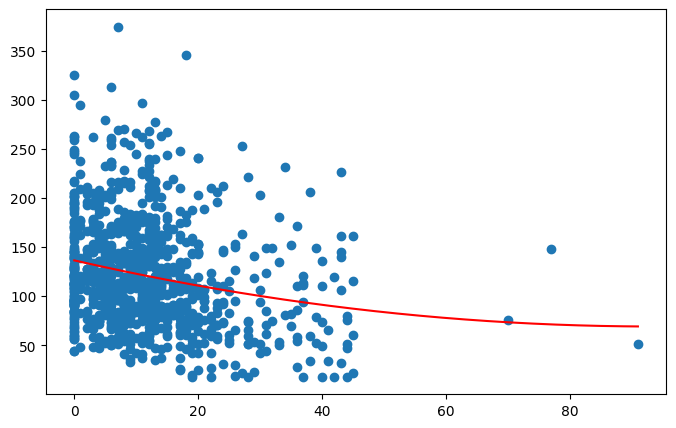

In [53]:
#Visualize
X_poly = poly_data[['Age_Years']]
y_poly = poly_data['Price_Lakhs']
age_range = np.linspace(X_poly.min().values[0], X_poly.max().values[0],200).reshape(-1,1)
age_range_transform = (poly_transform.transform(age_range))
price_point = poly_model.predict(age_range_transform)

plt.figure(figsize=(8,5))
plt.scatter(X_poly, y_poly)
plt.plot(age_range, price_point, color="red")
plt.show()

In [54]:
# SAVE THE FINAL MODEL
joblib.dump(ridge_pipeline,"property_price_regression_model.pkl")


['property_price_regression_model.pkl']

In [55]:
loaded_model = joblib.load("property_price_regression_model.pkl")

In [64]:
#first check features that we have
print(X.columns.tolist())

new_data = pd.DataFrame({'City': ['Hyderabad'], 
                         'Locality':['Kondapur'], 
                         'Property_Type':['Apartment'], 
                         'BHK': [3], 
                         'Built_Up_Area_sqft': [1650], 
                         'Carpet_Area_sqft':[1350], 
                         'Age_Years':[5], 
                         'Total_Floors':[20], 
                         'Bathrooms':[2], 
                         'Parking_Spaces':[1], 
                         'Furnishing_Status':['Furnished'], 
                         'Facing':['East'], 
                         'Gated_Community':['Yes'], 
                         'Distance_to_Metro_km':[5], 
                         'Distance_to_CBD_km':[10], 
                         'Nearby_Schools':[6], 
                         'Crime_Index':[10], 
                         'Amenities_Score':[7], 
                         'Monthly_Maintenance_INR':[90000], 
                         'Seller_Type':['Owner'], 
                         'Loan_Available': ['Yes'], 
                         'Annual_Property_Tax_INR':[50000], 
                         'Floor_Numeric': [8], 
                         'Listing_Year':[2026], 
                         'Listing_Month': [9], 
                         'Listing_Quarter':[3], 
                         'Days_Since_Listing':[1]})
predicted_price = loaded_model.predict(new_data)
print("Price of the house predicted by our model is Rs (Lakhs):",predicted_price)

['City', 'Locality', 'Property_Type', 'BHK', 'Built_Up_Area_sqft', 'Carpet_Area_sqft', 'Age_Years', 'Total_Floors', 'Bathrooms', 'Parking_Spaces', 'Furnishing_Status', 'Facing', 'Gated_Community', 'Distance_to_Metro_km', 'Distance_to_CBD_km', 'Nearby_Schools', 'Crime_Index', 'Amenities_Score', 'Monthly_Maintenance_INR', 'Seller_Type', 'Loan_Available', 'Annual_Property_Tax_INR', 'Floor_Numeric', 'Listing_Year', 'Listing_Month', 'Listing_Quarter', 'Days_Since_Listing']
Price of the house predicted by our model is Rs (Lakhs): [144.98826136]
